# Week 6 Assessment: Denoising Autoencoder on MNIST using PyTorch

## Objective
Build a deep learning model that removes noise from MNIST digit images using a Denoising Autoencoder.

## Dataset
MNIST Dataset

## Framework
PyTorch

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset

import matplotlib.pyplot as plt
import numpy as np

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [4]:
# Transform images to tensors
transform = transforms.ToTensor()

# Download MNIST
train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

# Custom dataset for adding Gaussian noise
class NoisyMNIST(Dataset):
    def __init__(self, dataset, noise_factor=0.5):
        self.dataset = dataset
        self.noise_factor = noise_factor

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        clean_img, label = self.dataset[idx]

        noise = torch.randn_like(clean_img) * self.noise_factor
        noisy_img = clean_img + noise
        noisy_img = torch.clamp(noisy_img, 0., 1.)

        return noisy_img, clean_img

noise_factor = 0.5

train_noisy = NoisyMNIST(train_dataset, noise_factor)
test_noisy = NoisyMNIST(test_dataset, noise_factor)

train_loader = DataLoader(train_noisy, batch_size=128, shuffle=True)
test_loader = DataLoader(test_noisy, batch_size=128, shuffle=False)

print("Training samples:", len(train_dataset))
print("Testing samples:", len(test_dataset))

100%|██████████| 9.91M/9.91M [00:00<00:00, 75.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 62.3MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 71.5MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.22MB/s]


Training samples: 60000
Testing samples: 10000


In [5]:
class DenoisingAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(28 * 28, 256),
            nn.ReLU(),

            nn.Linear(256, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU()
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(64, 128),
            nn.ReLU(),

            nn.Linear(128, 256),
            nn.ReLU(),

            nn.Linear(256, 28 * 28),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)

        latent = self.encoder(x)
        reconstructed = self.decoder(latent)

        reconstructed = reconstructed.view(-1, 1, 28, 28)
        return reconstructed


model = DenoisingAutoencoder().to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(model)

DenoisingAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=784, bias=True)
    (5): Sigmoid()
  )
)


In [6]:
epochs = 10

for epoch in range(epochs):
    model.train()
    running_loss = 0

    for noisy_imgs, clean_imgs in train_loader:

        noisy_imgs = noisy_imgs.to(device)
        clean_imgs = clean_imgs.to(device)

        optimizer.zero_grad()

        outputs = model(noisy_imgs)
        loss = criterion(outputs, clean_imgs)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Loss: {avg_loss:.6f}"
    )

Epoch [1/10] Loss: 0.064419
Epoch [2/10] Loss: 0.038394
Epoch [3/10] Loss: 0.031345
Epoch [4/10] Loss: 0.027714
Epoch [5/10] Loss: 0.024850
Epoch [6/10] Loss: 0.023210
Epoch [7/10] Loss: 0.021944
Epoch [8/10] Loss: 0.020976
Epoch [9/10] Loss: 0.020203
Epoch [10/10] Loss: 0.019585


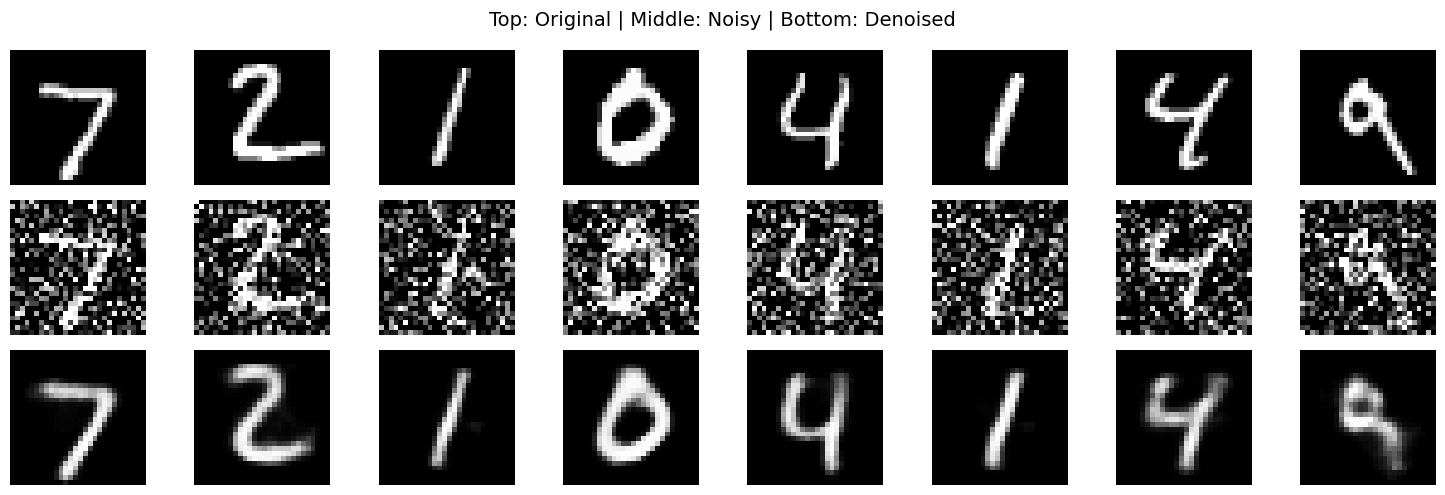

In [7]:
model.eval()

with torch.no_grad():
    noisy_imgs, clean_imgs = next(iter(test_loader))

    noisy_imgs = noisy_imgs.to(device)

    reconstructed = model(noisy_imgs)

    noisy_imgs = noisy_imgs.cpu()
    reconstructed = reconstructed.cpu()

# Display results
n = 8

plt.figure(figsize=(15, 5))

for i in range(n):

    # Clean
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(clean_imgs[i].squeeze(), cmap="gray")
    plt.axis("off")

    # Noisy
    ax = plt.subplot(3, n, i + n + 1)
    plt.imshow(noisy_imgs[i].squeeze(), cmap="gray")
    plt.axis("off")

    # Reconstructed
    ax = plt.subplot(3, n, i + 2*n + 1)
    plt.imshow(reconstructed[i].squeeze(), cmap="gray")
    plt.axis("off")

plt.suptitle(
    "Top: Original | Middle: Noisy | Bottom: Denoised",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [8]:
model.eval()

test_loss = 0

with torch.no_grad():

    for noisy_imgs, clean_imgs in test_loader:

        noisy_imgs = noisy_imgs.to(device)
        clean_imgs = clean_imgs.to(device)

        outputs = model(noisy_imgs)

        loss = criterion(outputs, clean_imgs)
        test_loss += loss.item()

avg_test_loss = test_loss / len(test_loader)

print(f"Average Test MSE Loss: {avg_test_loss:.6f}")

Average Test MSE Loss: 0.018936


# Observations

- The autoencoder successfully learned to reconstruct clean digit images from noisy inputs.
- Most digit structures were preserved while random Gaussian noise was removed.
- Some reconstructed digits appear slightly blurred due to information compression in the latent space.
- The reconstruction quality improved as training loss decreased.

# Conclusion

A Denoising Autoencoder was trained using noisy MNIST images as inputs and clean images as targets. The model effectively reduced noise while preserving the underlying digit structure.